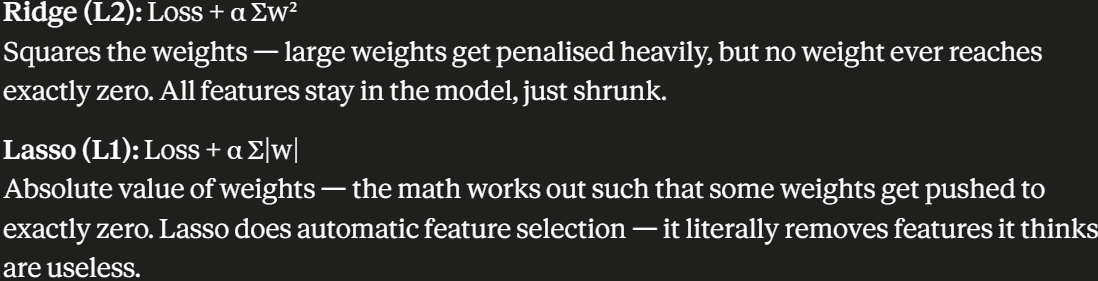

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
sns.set_theme(style="whitegrid")
print("Libraries loaded!")

Libraries loaded!


In [2]:
from sklearn.datasets import fetch_openml
ames = fetch_openml(name='house_prices', as_frame=True)
df = ames.frame
print("Shape:", df.shape)

Shape: (1460, 81)


In [3]:
print(df.dtypes.value_counts())
print("\nTarget Column: ")
print(df['SalePrice'].describe())

object     43
int64      35
float64     3
Name: count, dtype: int64

Target Column: 
count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64


In [4]:
# How many numeric vs categorical columns?
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

print(f"Numeric columns: {len(numeric_cols)}")
print(f"Categorical columns: {len(categorical_cols)}")
print(f"\nTarget (SalePrice) in numeric: {'SalePrice' in numeric_cols}")

Numeric columns: 38
Categorical columns: 43

Target (SalePrice) in numeric: True


In [5]:
# Missing values
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)
missing_df = pd.DataFrame({'Missing': missing, 'Pct': missing_pct})
missing_df = missing_df[missing_df['Missing'] > 0].sort_values('Pct', ascending=False)
print(f"Columns with missing values: {len(missing_df)}")
print(missing_df.head(10))

Columns with missing values: 19
              Missing   Pct
PoolQC           1453  99.5
MiscFeature      1406  96.3
Alley            1369  93.8
Fence            1179  80.8
FireplaceQu       690  47.3
LotFrontage       259  17.7
GarageCond         81   5.5
GarageType         81   5.5
GarageYrBlt        81   5.5
GarageFinish       81   5.5


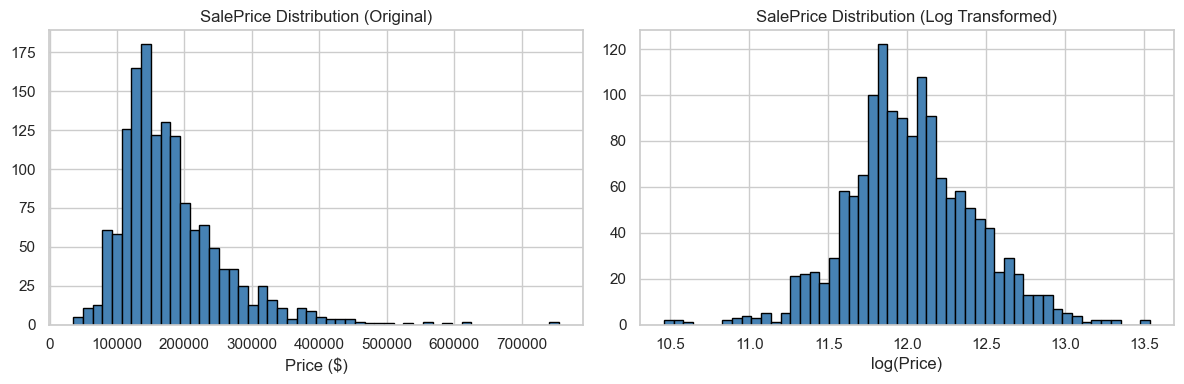

In [6]:
# Target distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df['SalePrice'], bins=50, color='steelblue', edgecolor='black')
axes[0].set_title('SalePrice Distribution (Original)')
axes[0].set_xlabel('Price ($)')

axes[1].hist(np.log1p(df['SalePrice']), bins=50, color='steelblue', edgecolor='black')
axes[1].set_title('SalePrice Distribution (Log Transformed)')
axes[1].set_xlabel('log(Price)')

plt.tight_layout()
plt.show()

In [7]:
# Top correlations with SalePrice
corr = df[numeric_cols].corr()
top_corr = corr['SalePrice'].abs().sort_values(ascending=False).head(10)
print(top_corr)

SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
Name: SalePrice, dtype: float64


In [8]:
data = df.copy()
data['SalePrice'] = np.log1p(data['SalePrice'])
if 'Id' in data.columns:
    data = data.drop('Id', axis=1)

num_cols = data.select_dtypes(include=[np.number]).columns.tolist()
num_cols.remove('SalePrice')
cat_cols = data.select_dtypes(include=['object', 'category']).columns.tolist()
print(f"Numeric features: {len(num_cols)}")
print(f"Categorical features: {len(cat_cols)}")

Numeric features: 36
Categorical features: 43


In [9]:
data[num_cols] = data[num_cols].fillna(data[num_cols].median())
for col in cat_cols:
    data[col] = data[col].fillna(data[col].mode()[0])
print("Missing values remaining:", data.isnull().sum().sum())

Missing values remaining: 0


In [10]:
data = pd.get_dummies(data, columns=cat_cols, drop_first=True)
print("Shape after encoding:", data.shape)
print("All dtypes numeric:", (data.dtypes != 'object').all())

Shape after encoding: (1460, 246)
All dtypes numeric: True


In [11]:
X = data.drop('SalePrice', axis=1).values
y = data['SalePrice'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

X_train: (1168, 245)
X_test: (292, 245)


In [12]:
models = {
    'Ridge':      Ridge(alpha=1.0),
    'Lasso':      Lasso(alpha=0.001),
    'ElasticNet': ElasticNet(alpha=0.001, l1_ratio=0.5),
}

results = {}

for name, model in models.items():
    # Cross validation on log target
    cv_scores = cross_val_score(
        model, X_train, y_train, 
        cv=5, scoring='r2'
    )
    
    # Train and evaluate
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    # Metrics on log scale
    r2 = r2_score(y_test, y_pred)
    rmse_log = np.sqrt(mean_squared_error(y_test, y_pred))
    
    # Convert back to dollars for interpretability
    rmse_dollars = np.sqrt(mean_squared_error(
        np.expm1(y_test), 
        np.expm1(y_pred)
    ))
    
    results[name] = {
        'CV R²': round(cv_scores.mean(), 4),
        'Test R²': round(r2, 4),
        'RMSE (log)': round(rmse_log, 4),
        'RMSE ($)': f"${rmse_dollars:,.0f}"
    }
    
    print(f"\n{name}")
    print(f"  CV R²:     {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
    print(f"  Test R²:   {r2:.4f}")
    print(f"  RMSE:      ${rmse_dollars:,.0f}")


Ridge
  CV R²:     0.7212 ± 0.1243
  Test R²:   0.7821
  RMSE:      $25,553

Lasso
  CV R²:     0.7281 ± 0.1676
  Test R²:   0.8422
  RMSE:      $25,775

ElasticNet
  CV R²:     0.7039 ± 0.1856
  Test R²:   0.8164
  RMSE:      $25,751


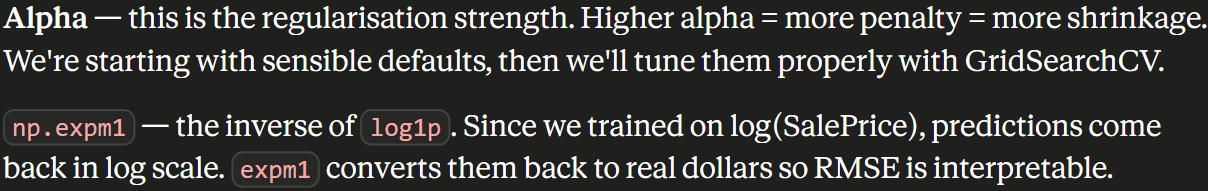
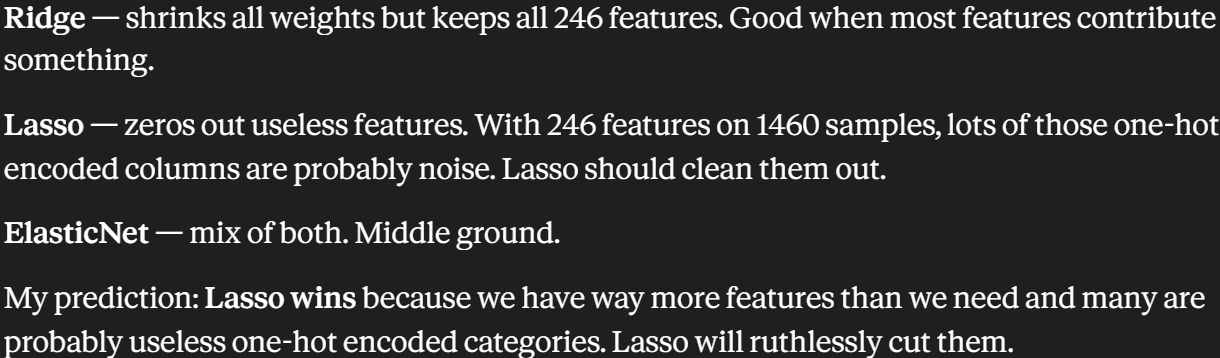

In [13]:
# How many features did Lasso zero out?
lasso_model = models['Lasso']
feature_names = data.drop('SalePrice', axis=1).columns

zero_weights = (lasso_model.coef_ == 0).sum()
nonzero_weights = (lasso_model.coef_ != 0).sum()

print(f"Total features: {len(feature_names)}")
print(f"Features zeroed out by Lasso: {zero_weights}")
print(f"Features kept by Lasso: {nonzero_weights}")

# Top 10 most important features Lasso kept
feat_imp = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': lasso_model.coef_
})
feat_imp['Abs_Coef'] = feat_imp['Coefficient'].abs()
feat_imp = feat_imp[feat_imp['Coefficient'] != 0].sort_values('Abs_Coef', ascending=False)

print(f"\nTop 10 features Lasso kept:")
print(feat_imp.head(10)[['Feature', 'Coefficient']])

Total features: 245
Features zeroed out by Lasso: 67
Features kept by Lasso: 178

Top 10 features Lasso kept:
              Feature  Coefficient
110  RoofMatl_CompShg     0.209015
114  RoofMatl_Tar&Grv     0.149948
15          GrLivArea     0.113292
116  RoofMatl_WdShngl     0.100988
115  RoofMatl_WdShake     0.083710
3         OverallQual     0.069564
5           YearBuilt     0.054261
113     RoofMatl_Roll     0.049637
112    RoofMatl_Metal     0.049048
4         OverallCond     0.039746


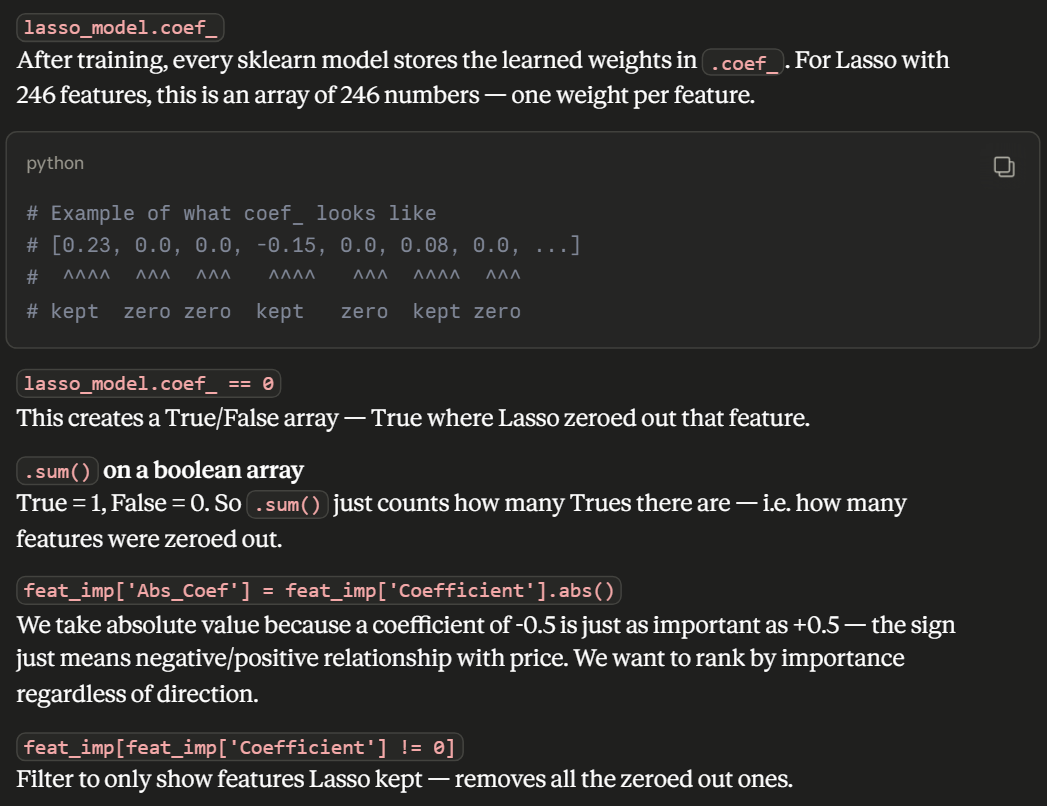

## Split data
X = df.drop("target", axis=1)
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Train
model.fit(X_train, y_train)

## Predict
y_pred = model.predict(X_test)

## Evaluate
accuracy = accuracy_score(y_test, y_pred)

# This is the standard train → predict → evaluate pipeline used in most supervised machine learning tasks.

In [17]:
from sklearn.model_selection import GridSearchCV
param_grid = {'alpha': [0.0001, 0.0005, 0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1.0]}
grid_search = GridSearchCV(
    Lasso(),
    param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)


print(f"Best alpha: {grid_search.best_params_['alpha']}")
print(f"Best CV R²: {grid_search.best_score_:.4f}")

best_lasso = grid_search.best_estimator_
y_pred_best = best_lasso.predict(X_test)

r2_best = r2_score(y_test, y_pred_best)
rmse_best = np.sqrt(
    mean_squared_error(
        np.expm1(y_test),
        np.expm1(y_pred_best)
    )
)

print(f"\nBest Lasso on test set:")
print(f"  R²:   {r2_best:.4f}")
print(f"  RMSE: ${rmse_best:,.0f}")

Best alpha: 0.01
Best CV R²: 0.8485

Best Lasso on test set:
  R²:   0.8840
  RMSE: $28,727


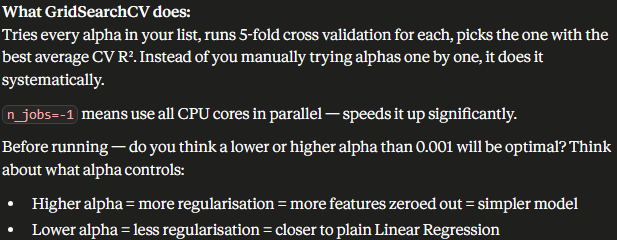

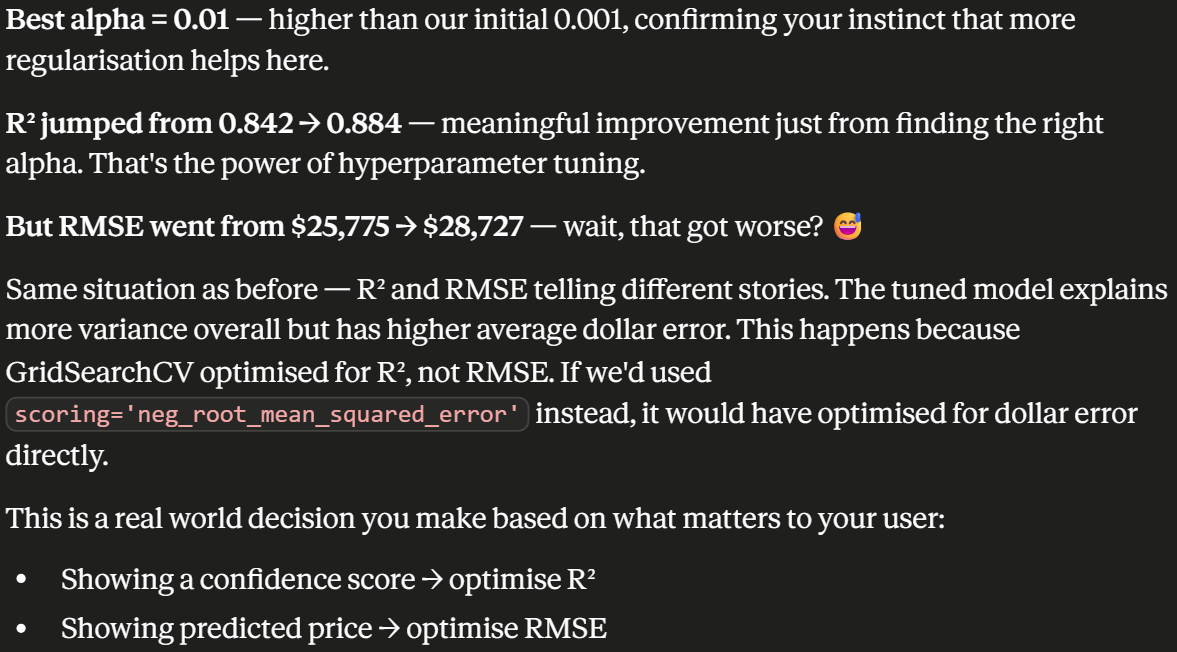

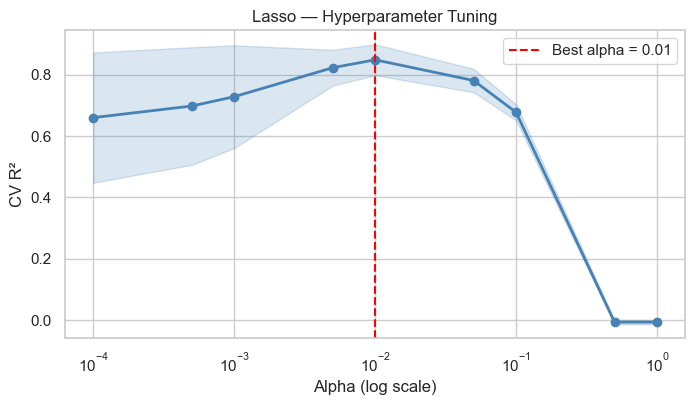

In [18]:
cv_results = pd.DataFrame(grid_search.cv_results_)

plt.figure(figsize=(8, 4))
plt.semilogx(
    cv_results['param_alpha'], 
    cv_results['mean_test_score'], 
    marker='o', color='steelblue', linewidth=2
)
plt.fill_between(
    cv_results['param_alpha'],
    cv_results['mean_test_score'] - cv_results['std_test_score'],
    cv_results['mean_test_score'] + cv_results['std_test_score'],
    alpha=0.2, color='steelblue'
)
plt.axvline(x=0.01, color='red', linestyle='--', label='Best alpha = 0.01')
plt.xlabel('Alpha (log scale)')
plt.ylabel('CV R²')
plt.title('Lasso — Hyperparameter Tuning')
plt.legend()
plt.grid(True)
plt.show()

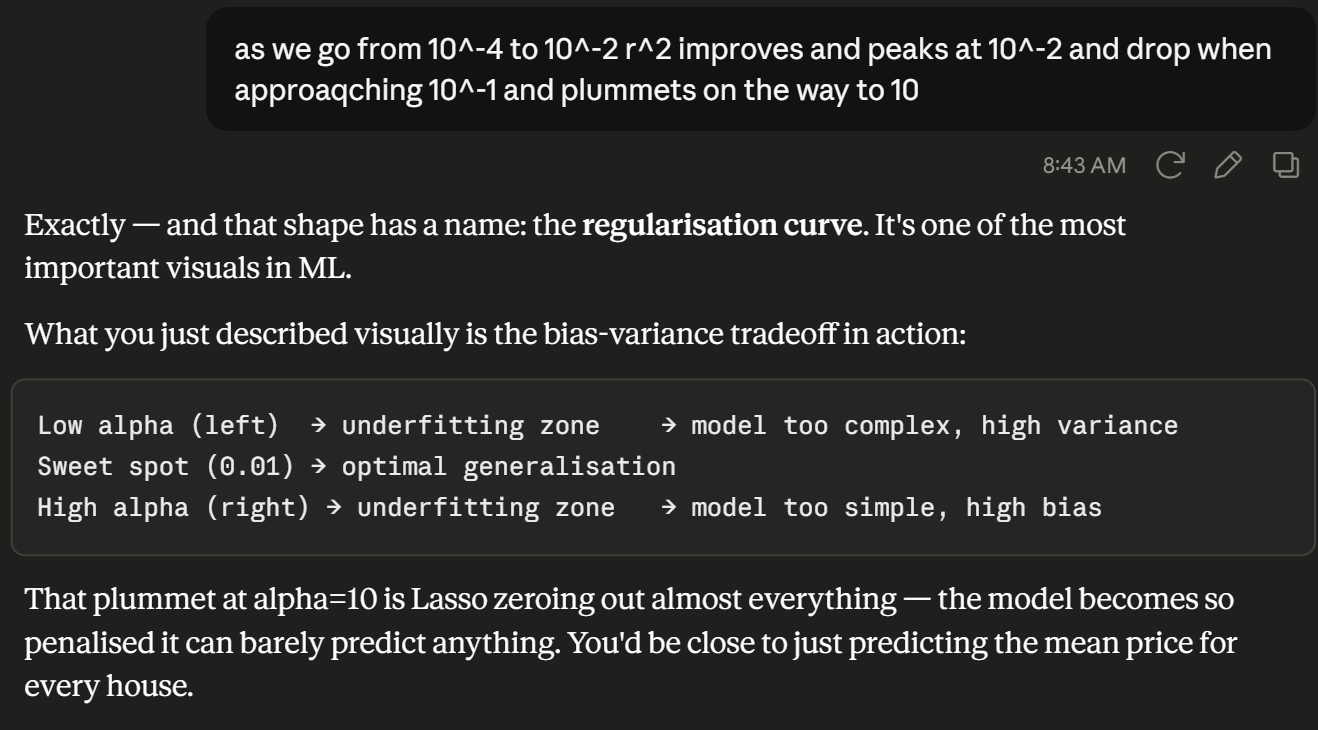

In [19]:
import joblib
import json

# Save best model and scaler
joblib.dump(best_lasso, '../housing_model.pkl')
joblib.dump(scaler, '../housing_scaler.pkl')

# Save feature columns
feature_cols = list(data.drop('SalePrice', axis=1).columns)
with open('../feature_cols.json', 'w') as f:
    json.dump(feature_cols, f)

# Save categorical columns and their categories for Flask
cat_info = {}
for col in cat_cols:
    cat_info[col] = list(df[col].astype(str).unique())
with open('../cat_info.json', 'w') as f:
    json.dump(cat_info, f)

print(f"Saved model, scaler, {len(feature_cols)} feature cols, {len(cat_info)} categorical mappings")

Saved model, scaler, 245 feature cols, 43 categorical mappings
